In [ ]:
NUM_AGENTS = 7
HEIGHT = 12
WIDTH = 12
SPAWN_PROB_PER_CELL = 0.05
DESPAWN_PROB_PER_CELL = 0.09

# Parameters
ENV_ITERATIONS = 100
DISCOUNT = 0.99
EPSILON = 0.1
LEARNING_RATE = 0.00002
BATCH_SIZE = 32


HIDDEN_FEATURES = 128
HIDDEN_LAYERS = 2

TARGET_UPDATE_FREQUENCY = 1000
MONTE_CARLO_DEPTH = 1000
CONV_CHANNELS = [32, 64, 64]

In [26]:
import sys
sys.path.append("../..")
from models.value_cnn import ValueCNNCentralized
import numpy as np
from orchard.environment import Action2D, OrchardBasic
from tqdm import tqdm
import torch
from scipy.stats import norm
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt

from models.value_cnn import Transition
from utils import ten_float
from dataclasses import dataclass
from typing import Any
from env_functions import *


In [27]:
def simulate_step(s: State, agent_idx: int, agent_positions: np.ndarray, action_vector: np.ndarray):
    """
    Simulates an agent taking an action. Does not modify in place.
    
    Returns:
        tuple: (reward: int, next_state: State, new_agent_positions: np.ndarray)
    """
    current_agents = s.agents
    current_apples = s.apples
    agent_pos = agent_positions[agent_idx]
    grid_shape = current_agents.shape
    
    new_position = np.clip(
        agent_pos + action_vector, [0, 0], np.array(grid_shape) - 1
    )
    
    next_agents = current_agents.copy()
    next_apples = current_apples.copy()
    
    next_agents[tuple(new_position)] += 1
    next_agents[tuple(agent_pos)] -= 1
    
    # The new positions array must be updated
    new_agent_positions = agent_positions.copy()
    new_agent_positions[agent_idx] = new_position
    
    reward = 0
    if next_apples[tuple(new_position)] > 0:
        next_apples[tuple(new_position)] -= 1
        reward = 1
        
    return reward, State(apples=next_apples, agents=next_agents), new_agent_positions

### Get CNN Centralized Estimate Value

In [28]:
history = {
    "loss": [],
    "reward_mean": [],
    "reward_std": [],
    "target_mean": [],
    "target_std": [],
    "pred_mean": [],
    "pred_std": [],
    "corr": [],
}

def log_batch_stats(net: ValueCNNCentralized, batch_size: int):
    """Compute and store one-line summary statistics based on a sample from the replay buffer."""
    with torch.no_grad():
        if len(net.memory) < batch_size:
            return
            
        device = next(net.parameters()).device

        transitions = net.memory.sample(batch_size)
        batch = Transition(*zip(*transitions))

        states = ten_float(np.stack(batch.state), device=device)
        next_states = ten_float(np.stack(batch.new_state), device=device)
        rewards = ten_float(np.array(batch.reward), device=device)

        preds = net.forward(states).squeeze(1)
        
        # CORRECTED: use net.discount instead of net.trainer.discount
        targets = rewards + net.discount * net.target_net(next_states).squeeze(1)

        preds_np, targets_np, rewards_np = preds.cpu().numpy(), targets.cpu().numpy(), rewards.cpu().numpy()
        corr = np.corrcoef(preds_np, targets_np)[0, 1] if len(preds_np) > 1 else np.nan

    history["reward_mean"].append(np.mean(rewards_np))
    history["reward_std"].append(np.std(rewards_np))
    history["target_mean"].append(np.mean(targets_np))
    history["target_std"].append(np.std(targets_np))
    history["pred_mean"].append(np.mean(preds_np))
    history["pred_std"].append(np.std(preds_np))
    history["corr"].append(corr)
def state_to_raw_dict(s: State) -> dict:
    return {"apples": s.apples, "agents": s.agents}



In [29]:
s_0 = init_empty_state(HEIGHT, WIDTH)
place_agents_randomly(s_0, NUM_AGENTS)
agent_positions = np.argwhere(s_0.agents == 1)

start_state = s_0.copy()
start_state.name = "Early State"
mid_state = s_0.copy()
mid_state.name = "Mid State"
late_state = s_0.copy()
late_state.name = "Late State"
s_t = s_0.copy()
for t in range(200):
    c = np.random.randint(0, len(agent_positions))
    action = Action2D.get_random_action()
        
    r_t, s_intermediate, agent_positions = simulate_step(s_t, c, agent_positions, action.vector)
    s_t_plus_1 = s_intermediate.copy()
    spawn_apples(s_t_plus_1, SPAWN_PROB_PER_CELL)
    despawn_apples(s_t_plus_1, DESPAWN_PROB_PER_CELL)
    s_t = s_t_plus_1
    if t == 10:
        start_state = s_t.copy()
        start_state.name = "Early State"
    if t == 50:
        mid_state = s_t.copy()
        mid_state.name = "Mid State"


late_state = s_t.copy()
late_state.name = "Late State"
    
states_to_evaluate = [s_0, start_state, mid_state, late_state]

for s in states_to_evaluate:
    print(f"Evaluating state: {s.name}")
    print(s.apples, s.agents)
    

Evaluating state: Empty State
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]] [[0 0 0 0 0 0]
 [0 1 1 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
Evaluating state: Early State
[[1 0 0 0 0 0]
 [0 0 0 1 1 0]
 [0 1 0 1 0 1]
 [0 0 0 0 0 1]
 [0 1 0 1 0 1]
 [0 0 0 1 0 0]] [[0 1 0 1 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
Evaluating state: Mid State
[[1 0 1 1 0 0]
 [0 0 1 0 0 0]
 [0 0 1 0 1 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 1]] [[0 0 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 0]]
Evaluating state: Late State
[[0 1 0 0 0 1]
 [0 0 1 0 1 0]
 [0 1 0 0 1 0]
 [1 1 0 1 0 0]
 [0 0 1 0 0 0]
 [1 1 0 0 0 0]] [[0 0 0 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 0]]


In [30]:
NUM_TO_AVERAGE_OVER = 100
for state in states_to_evaluate:
    total_values = []
    initial_agent_positions = np.argwhere(state.agents == 1)
    for n in tqdm(range(NUM_TO_AVERAGE_OVER), desc=f"iterating over {state.name}"):
        agent_positions = initial_agent_positions.copy()
        s_t = state.copy()
        total_value = 0
        discount_factor = 1.0
        for t in range(MONTE_CARLO_DEPTH):
            c = np.random.randint(0, NUM_AGENTS)
            action = Action2D.get_random_action()
            
            r_t, s_t_plus_1, agent_positions = simulate_step(s_t, c, agent_positions, action.vector)   
            spawn_apples(s_t_plus_1, SPAWN_PROB_PER_CELL)
            despawn_apples(s_t_plus_1, DESPAWN_PROB_PER_CELL)

            total_value += discount_factor * r_t
            discount_factor *= DISCOUNT
            s_t = s_t_plus_1
        total_values.append(total_value)
    avg_value = np.mean(total_values)
    print(f"Estimated true value of state:\n{state.name}\n is approximately: {avg_value}\n")

iterating over Empty State: 100%|██████████| 100/100 [00:00<00:00, 2614.15it/s]


Estimated true value of state:
Empty State
 is approximately: 0.7360835664046093



iterating over Early State: 100%|██████████| 100/100 [00:00<00:00, 3164.51it/s]


Estimated true value of state:
Early State
 is approximately: 1.5529757594758673



iterating over Mid State: 100%|██████████| 100/100 [00:00<00:00, 3011.27it/s]


Estimated true value of state:
Mid State
 is approximately: 0.8717681930624168



iterating over Late State: 100%|██████████| 100/100 [00:00<00:00, 3054.05it/s]

Estimated true value of state:
Late State
 is approximately: 1.6818792294233667



In [31]:
value_CNN_centralized = ValueCNNCentralized(HEIGHT, WIDTH, LEARNING_RATE, 
                                            DISCOUNT, HIDDEN_FEATURES, HIDDEN_LAYERS, 
                                            conv_channels=CONV_CHANNELS)
s_0 = init_empty_state(HEIGHT, WIDTH)
place_agents_randomly(s_0, NUM_AGENTS)
agent_positions = np.argwhere(s_0.agents == 1)


total_steps = 0

s_t = s_0.copy()
for t in tqdm(range(ENV_ITERATIONS), desc="Training"):
    c = np.random.randint(0, len(agent_positions))
    action = Action2D.get_random_action()
        
    r_t, s_intermediate, agent_positions = simulate_step(s_t, c, agent_positions, action.vector)
    s_t_plus_1 = s_intermediate.copy()
    spawn_apples(s_t_plus_1, SPAWN_PROB_PER_CELL)
    despawn_apples(s_t_plus_1, DESPAWN_PROB_PER_CELL)

    # 1. Convert states to the network input format
    processed_s_t = value_CNN_centralized.raw_state_to_nn_input(state_to_raw_dict(s_t))
    processed_s_t_plus_1 = value_CNN_centralized.raw_state_to_nn_input(state_to_raw_dict(s_t_plus_1))

    # 2. Add the experience to the replay buffer
    value_CNN_centralized.add_experience(processed_s_t, processed_s_t_plus_1, r_t)

    # 3. Train on a batch ONLY if the buffer is large enough
    if len(value_CNN_centralized.memory) >= BATCH_SIZE:
        log_batch_stats(value_CNN_centralized, BATCH_SIZE)
        value_CNN_centralized.train_batch(BATCH_SIZE)
    
    # 4. Periodically update the target network
    if total_steps % TARGET_UPDATE_FREQUENCY == 0:
        value_CNN_centralized.update_target_net()

    s_t = s_t_plus_1
    total_steps += 1




Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training: 100%|██████████| 100/100 [00:00<00:00, 182.15it/s]


In [32]:
for state in states_to_evaluate:
    raw_state = {"apples": state.apples, "agents": state.agents}
    predicted_value = value_CNN_centralized.get_model_reward_prediction_from_raw(raw_state)
    print(f"Predicted value of state {state.name} by trained CNN: {predicted_value.item()}")

Predicted value of state Empty State by trained CNN: 0.0413888543844223
Predicted value of state Early State by trained CNN: 0.04521862044930458
Predicted value of state Mid State by trained CNN: 0.04474493861198425
Predicted value of state Late State by trained CNN: 0.04670128598809242


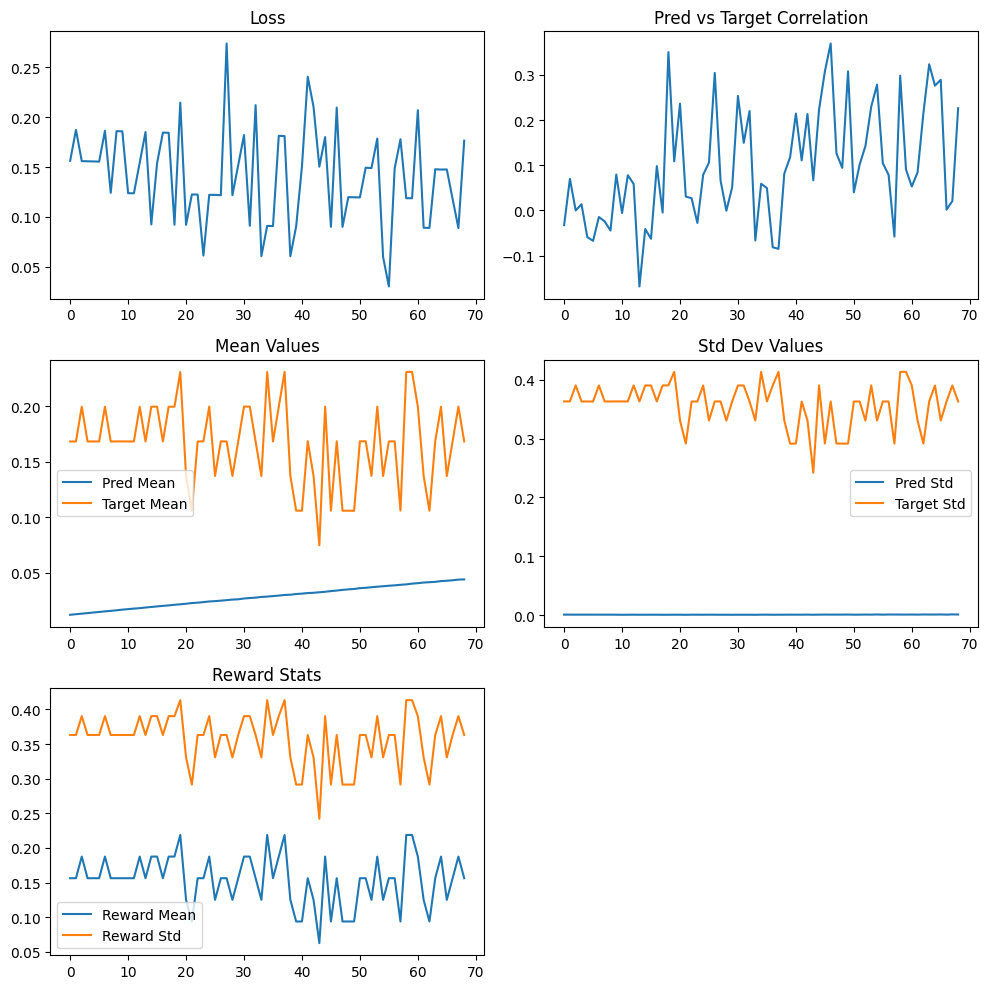

In [33]:
def plot_training_diagnostics(value_CNN_centralized):
    fig, axs = plt.subplots(3, 2, figsize=(10, 10))
    axs = axs.flatten()

    axs[0].plot(value_CNN_centralized.loss_history)
    axs[0].set_title("Loss")

    axs[1].plot(history["corr"])
    axs[1].set_title("Pred vs Target Correlation")

    axs[2].plot(history["pred_mean"], label="Pred Mean")
    axs[2].plot(history["target_mean"], label="Target Mean")
    axs[2].set_title("Mean Values")
    axs[2].legend()

    axs[3].plot(history["pred_std"], label="Pred Std")
    axs[3].plot(history["target_std"], label="Target Std")
    axs[3].set_title("Std Dev Values")
    axs[3].legend()

    axs[4].plot(history["reward_mean"], label="Reward Mean")
    axs[4].plot(history["reward_std"], label="Reward Std")
    axs[4].set_title("Reward Stats")
    axs[4].legend()

    axs[5].axis("off")
    plt.tight_layout()
    plt.show()

plot_training_diagnostics(value_CNN_centralized)
